# (20) Rot MNIST: static fit

host = ```chewie```, device = ```cuda:0```

**Motivation**:  <br>

- $\Delta \theta = 4.0$

and 1/3 rotations:

- $T_\text{train} = 30$

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Make a model

In [3]:
delta_theta = 4.0
n_full_rots = 1/3

t_train = int(n_full_rots * 360 / delta_theta)
t_tbptt = 1

kl_beta = 1.0

latent_channels = 128
latent_pixels = 8
latent_stride = 3

t_train

30

In [4]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST+rotate', model_type, 'ngd|lin')

cfg_vae['t_train'] = t_train
cfg_vae['t_tbptt'] = t_tbptt
cfg_vae['kl_beta'] = kl_beta

cfg_vae['latent_channels'] = latent_channels
cfg_vae['latent_pixels'] = latent_pixels
cfg_vae['latent_stride'] = latent_stride

cfg_vae['kws_feeder'] = {'delta_theta': delta_theta}

cfg_vae['fit_sigma'] = False
cfg_vae['fit_dt'] = False

cfg_tr['batch_size'] = 400

In [5]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

60000

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |   6.5 K    |
|     ———     |    ———     |
|    layer    |   6.5 K    |
+-------------+------------+

poisson_MNIST+rotate_t-(30,1)_b-1_kms-(128,8,3)_<ngd|lin>
b400-ep400-lr(0.002)_temp(0.05)_gr(150)_(2025_08_20,16:43)

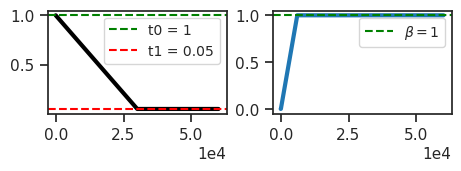

In [6]:
model.print()
tr.print()
tr.show_schedules()

In [7]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], device='cuda:0',
       dtype=torch.int32)

In [8]:
print(f"{tr.model.layer} \n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(128, 8, 8), input_sz=(1, 28, 28), temp=1) 
ConvDictionary(in_channels=128, out_channels=1, kernel_size=7, stride=3)

In [9]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 30, 't_tbptt': 1, 'kl_beta': 1.0, 'latent_channels': 
128, 'latent_pixels': 8, 'latent_stride': 3, 'enc_type': 'ngd', 'dec_type': 'lin', 'recon_mode': 'mse', 'dataset': 
'MNIST+rotate', 'dataset_name': 'MNIST', 'feeder': 'rotate', 'feeder_cfg': {'delta_theta': 4.0, 'theta_0': None}, 
'input_sz': (1, 28, 28), 'latent_sz': (128, 8, 8), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u':
(7.0,), 'du': (5.0,), 'dec': 3.45}, 'stochastic': True, 'optim_sigma': False, 'fit_sigma': False, 'fit_prior': 
True, 'fit_dt': False, 'seed': 0, 'track_stats': False, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/poisson_MNIST+rotate_t-(30,1)_b-1_kms-(128,8,3)_<ngd|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_MNIST+rotate_t-(30,1)_b-1_kms-(128,8,3)_<ngd|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}

{'lr': 0.002, 'epochs': 400, 'batch_size': 400, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 398.0, 'eta_min': 1e-06}, 'ema_rate': None, 'grad_clip': 
150, 'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [10]:
tr.train('fwd:static')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 209, avg loss: 39.107:  52%|███▏  | 209/400 [5:28:17<5:00:01, 94.25s/it]


KeyboardInterrupt: 

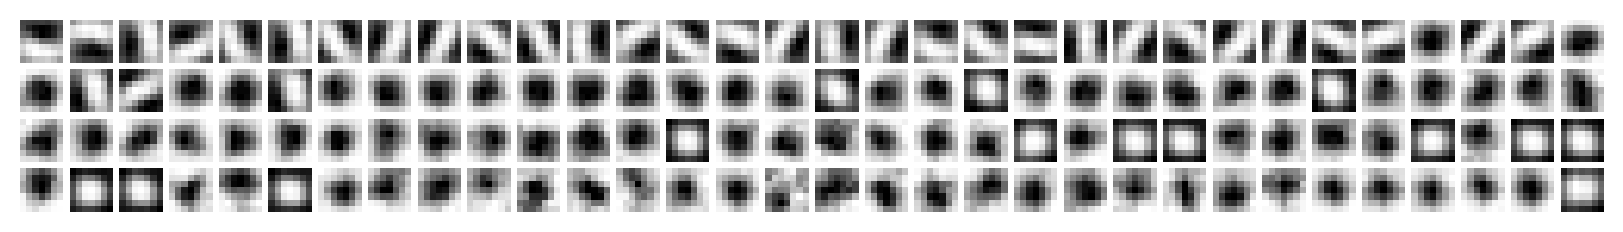

In [11]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████████| 5/5 [00:10<00:00,  2.19s/it]


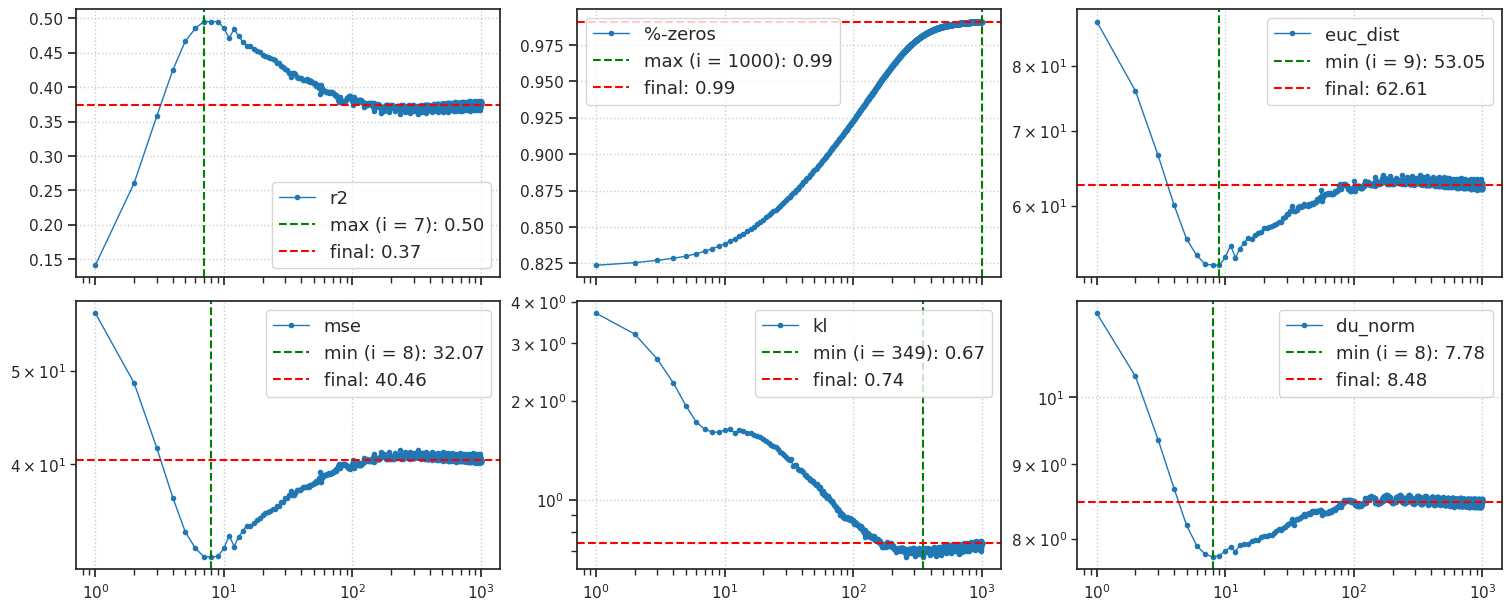

CPU times: user 11.8 s, sys: 48 ms, total: 11.8 s
Wall time: 11.8 s


In [17]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

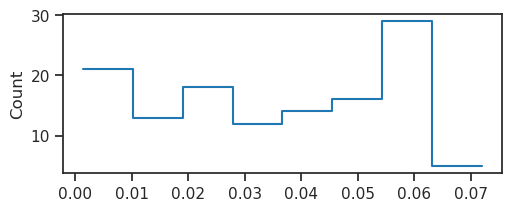

In [18]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)

fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

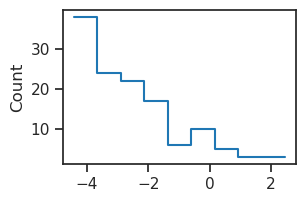

In [19]:
histplot(u0.ravel())
plt.show()

In [20]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.98749316, pvalue=5.886161189698778e-103)

In [24]:
output = tr.xtract_ftr(
    data='vld',
    t_total=32,
    save_freq=1,
    data_batch_sz=50,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)

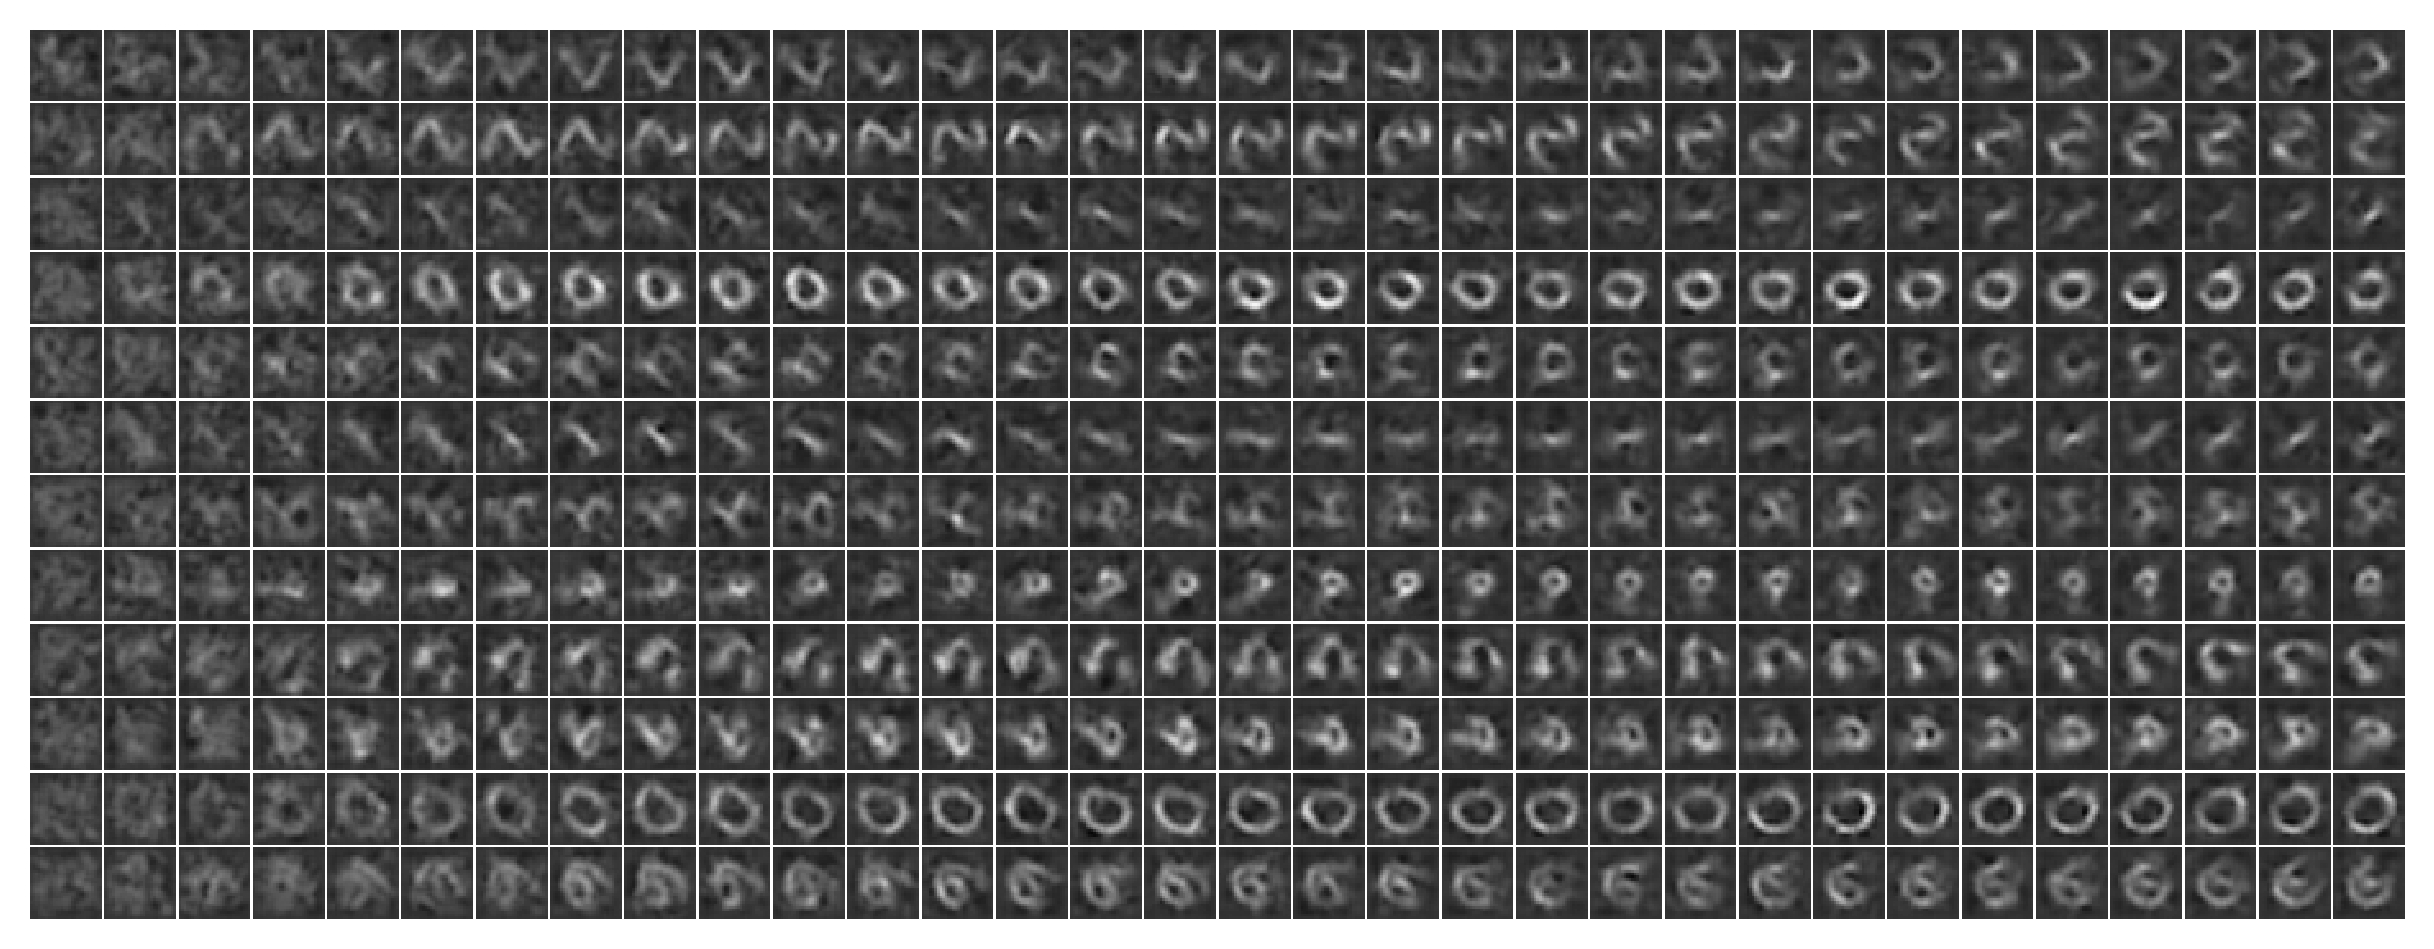

In [25]:
num = 12
x2p = output['recon'][:num].reshape(-1, 28, 28)
_ = plot_weights(x2p, method='none', nrows=num, dpi=300)

In [26]:
print(tr.model.cfg.feeder_cfg)

{'delta_theta': 4.0, 'theta_0': None}